# **NOTEBOOK 03 - PCA on Vertical Profiles**
---

**Goal:** decompose the vertical structure of the AMOC stream function into its dominant *modes of variability*. Each day in the RAPID record is a 307-dimensional vector — the stream function sampled at 307 depth levels. PCA asks a single, sharp question: across twenty years, how many independent vertical *shapes* do we actually need to describe how Ψ(z) changes, and what does each one mean physically?

**Guiding question:** how many independent modes are required to describe the variability of Ψ(z) over time, and what is the physical interpretation of each?

**Why this matters for the thesis.** This is objective O1.1 (Chapter 6, §6.2). The low-dimensional space PCA produces here is the analytical backbone of two later steps: it is the benchmark the autoencoder's latent space will be compared against, and it is the candidate coordinate system that Condition 3 of the perceptual prototype (Part II) will encode. If 2–3 components explain most of the variance, the entire twenty-year evolution of the AMOC's vertical anatomy can be drawn as a trajectory in a plane we can actually see.

**Inputs:** `moc_vertical.nc` — `stream_function_mar`, shape `(depth, time) = (307, 14,599)`, Sverdrups, RAPID 26.5°N, 2004–2024.

**Method note (orientation):** the file ships as `(depth, time)`, the right orientation for Hovmöller plots but the *wrong* one for PCA. We transpose to `(time, depth)` so that samples = days and features = depth levels. This is not cosmetic — it decides whether PCA finds modes of *vertical structure* or modes of *temporal evolution*. See Chapter 5, §5.4 for the full argument.

**Non-goals:** anomaly detection, forecasting, the autoencoder. Those are notebooks 04+. Here we stay strictly linear and interpretable.

**Author:** Enrico Vaccari  
**Date:** 01.06.2026

In [4]:
# Standard imports
import sys
from pathlib import Path

# Add 04_Code/ to PYTHONPATH so we can import the pipeline module
NOTEBOOK_DIR = Path.cwd()
PROJECT_CODE = NOTEBOOK_DIR.parent  # from notebooks/ up to 04_Code/
if str(PROJECT_CODE) not in sys.path:
    sys.path.insert(0, str(PROJECT_CODE))

# Scientific libraries
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Clean matplotlib defaults
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Project modules
from pipeline.paths import check_data_paths
from pipeline.data_loading import load_rapid_vertical

# Sanity check + load
check_data_paths()

ds_vert = load_rapid_vertical()
print(ds_vert)

# Transpose to (time, depth): samples = days, features = depth levels.
# This is THE orientation decision (see Ch.5 §5.4). Without it, PCA would
# decompose temporal modes at fixed depths instead of vertical structures.
profiles = ds_vert['stream_function_mar'].transpose('time', 'depth')

print("\n--- shape check ---")
print("profiles dims :", profiles.dims)
print("profiles shape:", profiles.shape, "  # expect (14599, 307)")
print("depth range   : {:.1f} → {:.1f} m".format(
    float(ds_vert['depth'].min()), float(ds_vert['depth'].max())))
print("any NaNs?     :", bool(np.isnan(profiles.values).any()))

✓  Copernicus AMOC timeseries: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\04_Activation_Phase\03_Data\raw\Copernicus\GLOBAL_OMI_NATLANTIC_amoc_max26N_timeseries.nc
✓  RAPID transports: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\04_Activation_Phase\03_Data\raw\RAPID\moc_transports_200404_2024327.nc
✓  RAPID vertical: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\04_Activation_Phase\03_Data\raw\RAPID\moc_vertical_200404_2024327.nc
<xarray.Dataset> Size: 36MB
Dimensions:              (depth: 307, time: 14599)
Coordinates:
  * depth                (depth) float64 2kB 0.0 19.87 ... 5.976e+03 5.995e+03
  * time                 (time) datetime64[ns] 117kB 2004-04-02 ... 2024-03-27
Data variables:
    stream_function_mar  (depth, time) float64 36MB ...
Attributes:
    Title:                         RAPID streamfunction
    Institution:                   National Oceanog

In [22]:
# Where are the NaNs? Diagnose before deciding the fix.
X = profiles.values  
nan_mask = np.isnan(X)                     # (14599, 307) boolean
total_nans = nan_mask.sum()
print(f"Total NaN entries: {total_nans:,}  ({100*total_nans/X.size:.3f}% of matrix)\n")

# --- Are whole DAYS missing? (rows entirely NaN) ---
rows_all_nan = nan_mask.all(axis=1)         # True where a full day is NaN
rows_any_nan = nan_mask.any(axis=1)         # True where a day has >=1 NaN
print("Days (rows):")
print(f"  fully NaN        : {rows_all_nan.sum():,}")
print(f"  partially NaN    : {(rows_any_nan & ~rows_all_nan).sum():,}")
print(f"  fully valid      : {(~rows_any_nan).sum():,}")

# --- Are whole DEPTHS missing? (columns entirely NaN) ---
cols_all_nan = nan_mask.all(axis=0)         # True where a full depth level is NaN
cols_any_nan = nan_mask.any(axis=0)
print("\nDepth levels (cols):")
print(f"  fully NaN        : {cols_all_nan.sum()}")
print(f"  partially NaN    : {(cols_any_nan & ~cols_all_nan).sum()}")
print(f"  fully valid      : {(~cols_any_nan).sum()}")

# --- If there are fully-NaN days, when are they? (gaps tell a story) ---
if rows_all_nan.any():
    times = ds_vert['time'].values
    missing_dates = pd.to_datetime(times[rows_all_nan])
    print(f"\nFirst few missing days: {missing_dates[:5].date.tolist()}")
    print(f"Last few missing days : {missing_dates[-5:].date.tolist()}")
    # Are they contiguous blocks or scattered?
    idx = np.where(rows_all_nan)[0]
    gaps = np.split(idx, np.where(np.diff(idx) > 1)[0] + 1)
    print(f"Number of distinct missing blocks: {len(gaps)}")
    print(f"Largest block length: {max(len(g) for g in gaps)} consecutive days")

    times_pd = pd.to_datetime(ds_vert['time'].values)

Total NaN entries: 921  (0.021% of matrix)

Days (rows):
  fully NaN        : 3
  partially NaN    : 0
  fully valid      : 14,596

Depth levels (cols):
  fully NaN        : 0
  partially NaN    : 307
  fully valid      : 0

First few missing days: [datetime.date(2024, 3, 26), datetime.date(2024, 3, 26), datetime.date(2024, 3, 27)]
Last few missing days : [datetime.date(2024, 3, 26), datetime.date(2024, 3, 26), datetime.date(2024, 3, 27)]
Number of distinct missing blocks: 1
Largest block length: 3 consecutive days
Duplicate timestamps: 0
DatetimeIndex([], dtype='datetime64[ns]', freq=None)


The dataset contains 921 NaN entries, representing just 0.021% of the full
matrix (14,599 days × 307 depth levels). The missing data is structurally
clean: exactly 3 days are entirely absent, no day is partially c\orrupted,
and no depth level is systematically missing. All 307 levels appear as
"partially NaN" only because they each inherit one missing value from those
3 days — not because of any instrument failure at a given depth.

The missing days form a single contiguous block at the very end of the record
(26–27 March 2024), with 26 March appearing twice due to a duplicated
timestamp. No other duplicate timestamps were found in the dataset.
The arithmetic is exact: 3 days × 307 levels = 921 NaN entries.
Given the negligible size of the gap and its position at the tail of a
~40-year record, the 3 incomplete days were simply dropped, leaving
**14,596 fully valid profiles** for all subsequent analysis.

In [26]:
# Since 26 in the missing dates appears twice, let's check if it's the same block or two separate ones and let's also check if there are some repeated days in general
unique_times, counts = np.unique(times_pd, return_counts=True)
repeated_mask = counts > 1
repeated_times = unique_times[repeated_mask]
repeated_counts = counts[repeated_mask]

print(f"Repeated timestamps: {len(repeated_times)}")
for t, c in zip(pd.to_datetime(repeated_times), repeated_counts):
    print(f"  {t.date()}  →  appears {c} times")

Repeated timestamps: 0


## **1. Preprocessing: Profile Centering**

Before running PCA we fix two choices and justify them physically.

> **Centering (subtract the mean profile) — yes.** PCA decomposes the covariance matrix, which is defined relative to the mean. Without centering, the first component would simply reproduce the climatological mean profile (the canonical bulge at ~1000 m seen in NB01) instead of the dominant axis of *variability around* it. Centering ensures the components describe how Ψ(z) **departs** from its average shape — which is the question.

> **Standardizing (divide each depth by its std) — no.** Standardization is for features in *different units*. Here every feature is the same physical quantity (stream function, Sv) at a different depth. The variance differences between depths are not a scale artefact — they **are the signal**: the ~1000 m layer varies strongly because that is where the overturning lives; abyssal layers are nearly still. Standardizing would inflate the quiet deep layers to the same importance as the AMOC core, giving equal voice to a whisper and a shout when the volume *is* the information.

This is *covariance-based PCA* — equivalent to **EOF analysis** (Empirical Orthogonal Functions), the standard form of this technique in oceanography and climate science (Hannachi et al., 2007; von Storch & Zwiers, 1999).

**Things to verify before committing:** 
- the 307 depth levels are not equispaced (denser near the surface, per Ch.5 §5.2). Strictly, EOF analysis weights each level by its layer thickness so that closely-spaced upper levels don't over-count. We check the actual depth spacing first and decide whether the weighting matters, rather than assuming.
- in order to compare the two available datasets, we had previously changed the RAPID frequency to monthly. PCA on vertical profile is almost non-sensitive to the frequency choice, as it looks into vertical shapes, not the time variable. Averaging out the month would get rid of the noise perturbation but not the main vertical shapes. Yet, daily frequency for notebook 4 will be strictly necessary as it will be directly fed into the autoencoder and early warning signals (autocorrelation lag-1 and growing variance) live on the time axis. Monthly aggregation would distroy information. Therefore, we keep the daily frequency across all ML notebooks to make sure the entire pipeline works on the same matrix, without resolution changes half-way through.
- for temporal projections (PC1(t) and PC2(t), we can apply a rolling mean for visualization purposes and readability, but on only on the output.

Depth levels      : 307
Surface → seafloor: 0.0 → 5995.1 m

Layer spacing (dz):
  min   : 19.33 m
  median: 19.59 m
  max   : 19.87 m
  ratio max/min: 1.0x


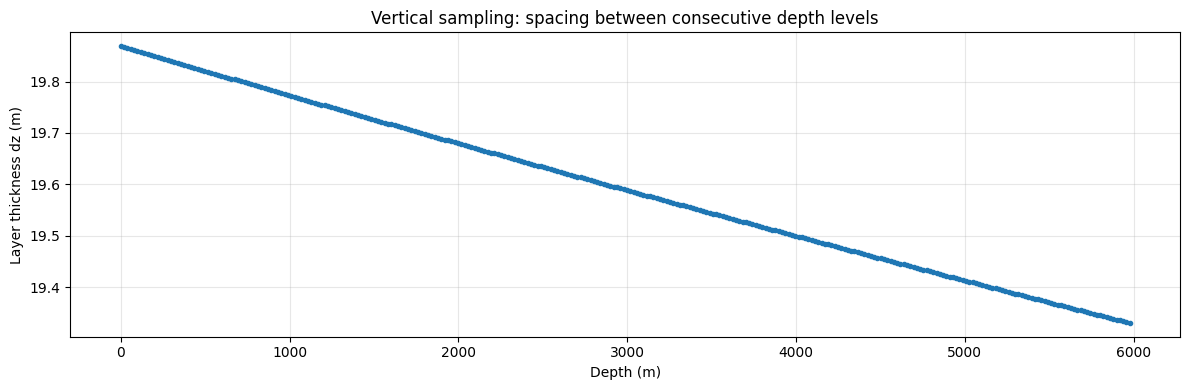

In [6]:
# Inspect the depth axis: is sampling uniform enough to skip layer weighting?
depth = ds_vert['depth'].values
dz = np.diff(depth)  # spacing between consecutive levels

print("Depth levels      :", len(depth))
print("Surface → seafloor: {:.1f} → {:.1f} m".format(depth.min(), depth.max()))
print("\nLayer spacing (dz):")
print("  min   : {:.2f} m".format(dz.min()))
print("  median: {:.2f} m".format(np.median(dz)))
print("  max   : {:.2f} m".format(dz.max()))
print("  ratio max/min: {:.1f}x".format(dz.max() / dz.min()))

# Quick visual: how spacing changes with depth
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(depth[:-1], dz, marker='.', linewidth=1)
ax.set_xlabel('Depth (m)')
ax.set_ylabel('Layer thickness dz (m)')
ax.set_title('Vertical sampling: spacing between consecutive depth levels')
plt.tight_layout()
plt.show()

## **2. Depth sampling is uniform → no layer weighting needed**

The depth axis is sampled on a **near-uniform grid**: spacing ranges 19.33–19.87 m (median 19.59 m) across the full column, a max/min ratio of ~1.03×. The ~3% drift with depth is physically negligible.

> **Consequence:** layer-thickness weighting is unnecessary. With equispaced levels, weighting by dz multiplies every level by an (almost) identical constant — an operation PCA absorbs with no effect on the loadings or variance proportions. We therefore run **plain covariance-based PCA (centered, unscaled, unweighted)** and state the uniform-grid justification explicitly.

> *Note for Ch.5 §5.2:* the data shows near-uniform spacing, not denser sampling in the upper ocean. The text should be adjusted to "≈19.6 m near-uniform grid" — what the data actually demonstrates.

In [21]:
from sklearn.decomposition import PCA

# --- Drop the 3 fully-NaN days (tail of the record, see diagnosis above) ---
valid_days = ~np.isnan(X).any(axis=1)            # True for complete profiles (~ inverts the mask)
X_clean = X[valid_days]                          # filters to only the valid rows (days) (14596, 307)
times_clean = ds_vert['time'].values[valid_days] # keep aligned time axis for later

n_dropped = (~valid_days).sum()
print(f"Dropped {n_dropped} incomplete days → X_clean {X_clean.shape}")
# print dropped dates for sanity check
missing_dates = pd.to_datetime(ds_vert['time'].values[~valid_days])
print(f"Dropped days: {missing_dates[:5].date.tolist()}")

# --- Sanity check: ensure no NaNs remain ---
assert not np.isnan(X_clean).any(), "NaNs remain — stop and re-check"
print("No NaNs remain. Proceeding to PCA.\n")

# --- Covariance-based PCA: centered (sklearn default), unscaled, unweighted ---
pca = PCA()                                       # keep all components to see full spectrum
scores = pca.fit_transform(X_clean)               # (14596, 307): each day in PC space

mean_profile = pca.mean_                          # climatological Ψ̄(z), shape (307,)
explained = pca.explained_variance_ratio_
cum = np.cumsum(explained)

print("--- Variance explained ---")
for i in range(6):
    print(f"  PC{i+1}: {explained[i]*100:6.2f}%   (cumulative {cum[i]*100:6.2f}%)")

print(f"\nComponents for >80% variance: {np.argmax(cum >= 0.80) + 1}")
print(f"Components for >90% variance: {np.argmax(cum >= 0.90) + 1}")
print(f"Components for >95% variance: {np.argmax(cum >= 0.95) + 1}")

Dropped 3 incomplete days → X_clean (14596, 307)
Dropped days: [datetime.date(2024, 3, 26), datetime.date(2024, 3, 26), datetime.date(2024, 3, 27)]
No NaNs remain. Proceeding to PCA.

--- Variance explained ---
  PC1:  89.82%   (cumulative  89.82%)
  PC2:   8.03%   (cumulative  97.86%)
  PC3:   1.57%   (cumulative  99.42%)
  PC4:   0.37%   (cumulative  99.80%)
  PC5:   0.12%   (cumulative  99.91%)
  PC6:   0.05%   (cumulative  99.97%)

Components for >80% variance: 1
Components for >90% variance: 2
Components for >95% variance: 2


## **4. Variance spectrum: the AMOC's vertical variability is near-1D**

| Mode | Variance | Cumulative |
|---|---|---|
| PC1 | 89.82% | 89.82% |
| PC2 | 8.03% | 97.86% |
| PC3 | 1.57% | 99.42% |
| PC4+ | <0.4% each | → 100% |

**Reading.** A *single* mode explains ~90% of all variability in the vertical structure; two modes reach ~98%. The expectation stated in Ch.5 ("2–3 modes >80%") is not just met — it is exceeded: the variability is effectively **one-dimensional**, with a weak but real second mode.

> **Physical meaning.** Day to day, over twenty years, the AMOC's vertical anatomy mostly does *one thing*: it strengthens and weakens along a single coherent shape (PC1). Like a spring that, in principle, could deform many ways but in practice mostly just stretches and compresses along its axis. PC2 (8%) is the second motion — likely a vertical shift in the depth of the overturning maximum rather than a change in its intensity — an order of magnitude weaker.

> **Why this is the right kind of result.** *(i)* For Part II: the latent space the experiential prototype must encode is **2-D at 97.9% fidelity** — twenty years of vertical structure can be drawn as a trajectory in a plane with negligible loss. *(ii)* For O1.2: it sets a hard benchmark — a 2-latent autoencoder must beat 97.9% reconstruction to justify its non-linearity. *(iii)* The elbow after PC2 is unambiguous, so the choice of how many modes to keep is made by the data, not by a threshold picked by hand.

> **A caveat to carry into the writing.** This low dimensionality is partly a property of the stream function itself: Ψ(z) is a depth-integrated, smooth field, structurally predisposed to vary coherently — more so than a raw level-wise field like temperature or salinity would. The result is real, but it is partly *inherited* from how Ψ is constructed. Stating this strengthens the interpretation rather than weakening it.

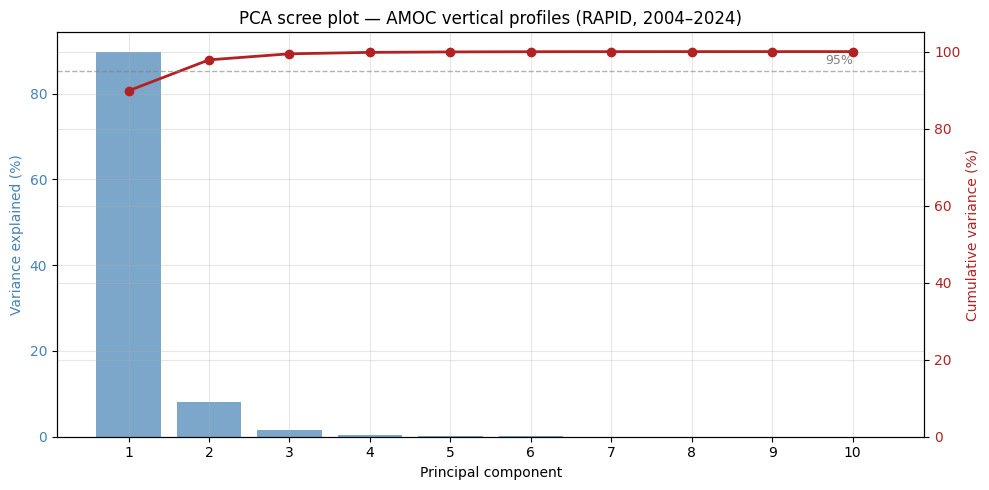

In [8]:
# Scree plot: individual + cumulative variance explained.
n_show = 10  # only the first 10 modes are meaningful; the rest is noise
modes = np.arange(1, n_show + 1)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Individual variance (bars)
ax1.bar(modes, explained[:n_show] * 100, alpha=0.7, color='steelblue',
        label='Individual')
ax1.set_xlabel('Principal component')
ax1.set_ylabel('Variance explained (%)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(modes)

# Cumulative variance (line, second axis)
ax2 = ax1.twinx()
ax2.plot(modes, cum[:n_show] * 100, color='firebrick', marker='o',
         linewidth=2, label='Cumulative')
ax2.set_ylabel('Cumulative variance (%)', color='firebrick')
ax2.tick_params(axis='y', labelcolor='firebrick')
ax2.set_ylim(0, 105)
ax2.axhline(95, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax2.text(n_show, 96, '95%', ha='right', va='bottom', color='gray', fontsize=9)

ax1.set_title('PCA scree plot — AMOC vertical profiles (RAPID, 2004–2024)')
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

> **Reading the scree plot.** PC1 dominates (~90%); PC2 is a small step (~8%); from PC3 onward the bars collapse onto the axis and the cumulative curve goes flat. The sharp knee between PC2 and PC3 is a textbook **elbow** — the point past which additional modes describe noise, not structure.

> **Decision (Cattell's scree criterion; Cattell, 1966).** Retain the modes *before* the detritus tail begins — here, **PC1 and PC2** (PC3 optional, as a minor physical refinement). The choice is read directly off the geometry of the curve, not imposed by an arbitrary variance threshold. The "scree" is the rubble at a mountain's foot: everything from PC3 on is rubble.

> **Figure status.** This is **Figure 6.x** for §6.2.2 (results characterization) — the empirical justification for the 2-mode latent space that the rest of the pipeline builds on.

> **Modes.** So far, we have come to know how many modes there are and how much of the dataset variability they explain, but we don't know what they are. The loadings - the vertical shapes themselves - coincide with where PC1 and PC2 stop being abstract numbers and become profile readable against the anatomy of AMOC we have already described. The hypothesis is that PC1 is the current intensity and PC2 is the depth current. 


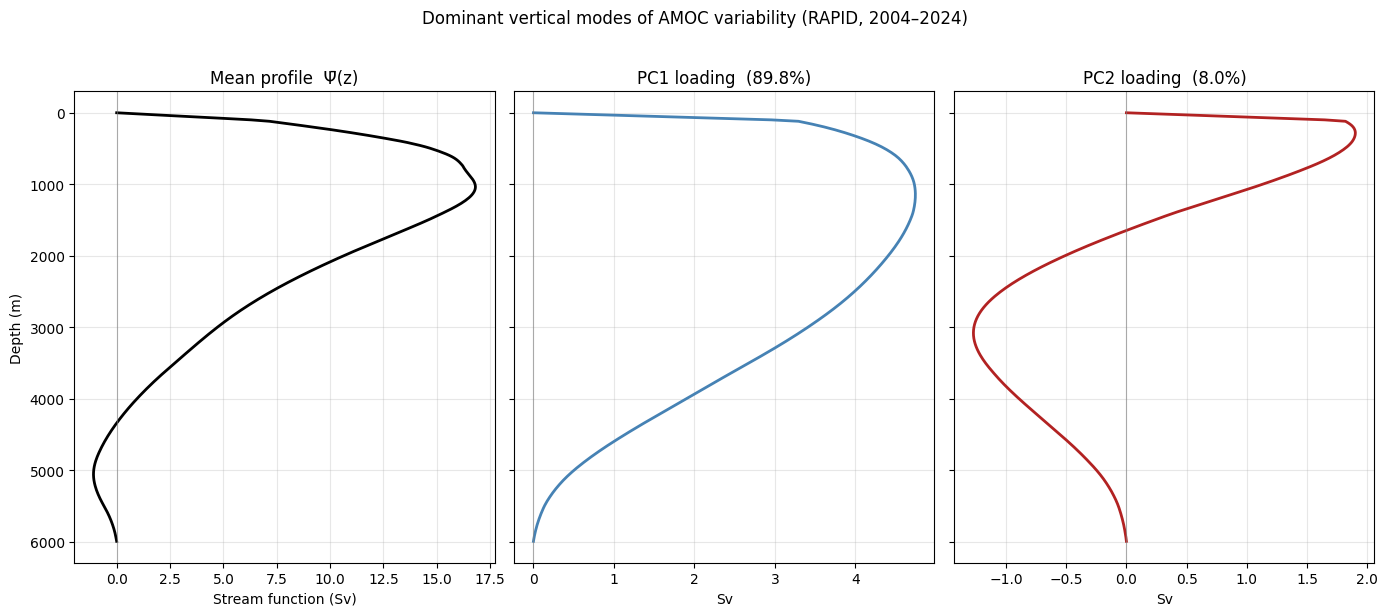

PC1 peaks at 1149 m  (amplitude +4.75 Sv)
PC2 peaks at 278 m  (amplitude +1.90 Sv)
PC2 sign changes: 1 (a dipole → vertical shift; a monopole → intensity change)


In [9]:
# Loadings (EOFs): the vertical shapes of the dominant modes.
# sklearn's components_ are unit-length eigenvectors (dimensionless, they only show directions).
# Scale each by sqrt(its eigenvalue) to express it in Sv — the typical
# amplitude of the variation that mode represents (Hannachi et al., 2007).
depth = ds_vert['depth'].values
scale = np.sqrt(pca.explained_variance_)                 # one value per mode

eof1 = pca.components_[0] * scale[0]                      # PC1 shape, in Sv
eof2 = pca.components_[1] * scale[1]                      # PC2 shape, in Sv

fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharey=True)

# Panel A: the mean profile (context — the shape the modes perturb)
axes[0].plot(mean_profile, depth, color='black', linewidth=2)
axes[0].set_title('Mean profile  Ψ̄(z)')
axes[0].set_xlabel('Stream function (Sv)')
axes[0].set_ylabel('Depth (m)')
axes[0].invert_yaxis()                                   # surface at top
axes[0].axvline(0, color='gray', linewidth=0.8, alpha=0.6)

# Panel B: PC1 loading
axes[1].plot(eof1, depth, color='steelblue', linewidth=2)
axes[1].set_title(f'PC1 loading  ({explained[0]*100:.1f}%)')
axes[1].set_xlabel('Sv')
axes[1].axvline(0, color='gray', linewidth=0.8, alpha=0.6)

# Panel C: PC2 loading
axes[2].plot(eof2, depth, color='firebrick', linewidth=2)
axes[2].set_title(f'PC2 loading  ({explained[1]*100:.1f}%)')
axes[2].set_xlabel('Sv')
axes[2].axvline(0, color='gray', linewidth=0.8, alpha=0.6)

plt.suptitle('Dominant vertical modes of AMOC variability (RAPID, 2004–2024)',
             y=1.02)
plt.tight_layout()
plt.show()

# Quick numeric read: where does each mode peak?
print(f"PC1 peaks at {depth[np.argmax(np.abs(eof1))]:.0f} m  "
      f"(amplitude {eof1[np.argmax(np.abs(eof1))]:+.2f} Sv)")
print(f"PC2 peaks at {depth[np.argmax(np.abs(eof2))]:.0f} m  "
      f"(amplitude {eof2[np.argmax(np.abs(eof2))]:+.2f} Sv)")
print(f"PC2 sign changes: {np.sum(np.diff(np.sign(eof2[eof2 != 0])) != 0)} "
      f"(a dipole → vertical shift; a monopole → intensity change)")

## **5. What the modes are: intensity (PC1) + vertical redistribution (PC2)**

> **PC1 — intensity (the spring).** The loading is a **monopole**: same sign at all depths, peaking at ~1000 m — exactly where the mean profile peaks. PC1 therefore *reproduces the shape of the mean profile*. When its score rises, the entire overturning cell strengthens while keeping its shape; when it falls, the whole cell weakens coherently. This single mode is ~90% of what the AMOC does day to day: it breathes along one axis. The spring, made visible.

> **PC2 — vertical redistribution (the see-saw).** The loading **changes sign with depth**: positive in the upper column (~200–300 m), negative below (~3000 m), crossing zero at ~1500–2000 m. This is a **dipole**. PC2 does not change *how much* overturning there is — it changes *at what depth* it happens, pivoting transport around a fulcrum near the zero-crossing. Positive score = weight shifted upward; negative = weight shifted deep.

> **An honest caveat for the writing.** PC2's dipolar shape *partly* reflects the orthogonality constraint: being orthogonal to a positive monopole (PC1) forces a sign change. This does not make PC2 an artefact — it captures real variability (8%, ten times the noise tail) — but it should be described as a *vertical redistribution mode whose dipolar form partly follows from orthogonality to PC1*, not over-interpreted as an independently named oceanographic mechanism.

> **Convergence with the literature.** The hierarchy "dominant intensity mode + secondary vertical-shift mode" matches independent EOF studies of the 26°N MOC vertical structure (Roberts et al., 2013 — to confirm exact figures at writing time). Convergence with independent observational work is the strongest validation an exploratory decomposition can have.

> **Figure status.** Figure 6.x for §6.2.3 (interpretation of dominant modes) — the physical reading that complements the scree plot's "how many".

Ψ(z,t)=Ψ(z)+a1​(t)PC1(z)+a2​(t)PC2(z)+⋯

Therefore ocean says that "its second-order variability lives close to the surface. Surface layers have more freedom to move and respond to wind forcing and seasonal variability more quickly, whereas the abyss is more inert.

> *Quantified:* PC1 peaks at 1149 m (±4.75 Sv typical amplitude), tracking the mean-profile maximum — the intensity mode. PC2's strongest lobe sits high in the column at 278 m (±1.90 Sv), with the dipole fulcrum near 1500–2000 m: its vertical redistribution is anchored in the upper ocean, where wind-driven (Ekman) and seasonal variability are freest to act, against a more inert abyss.

## **6. The modes in motion: temporal projections & the PC1–PC2 trajectory**

The loadings are static shapes. Their **scores** — each day projected onto each mode — are how those shapes moved over twenty years. PC1(t) is the intensity time series; PC2(t) is the vertical-redistribution time series. The PC1–PC2 plane is the **2-D latent space** (97.9% fidelity) that Condition 3 of the prototype will encode: twenty years of vertical anatomy as a single path.

> **Display choice.** Daily scores are noisy (Ekman, eddies). We plot two layers: raw daily (faint, full honesty — nothing hidden) and a rolling mean on top (for legibility). The smoothing is applied to the *result*, for reading — never to the input. This is the legitimate "average-after-to-see, never average-before" distinction.

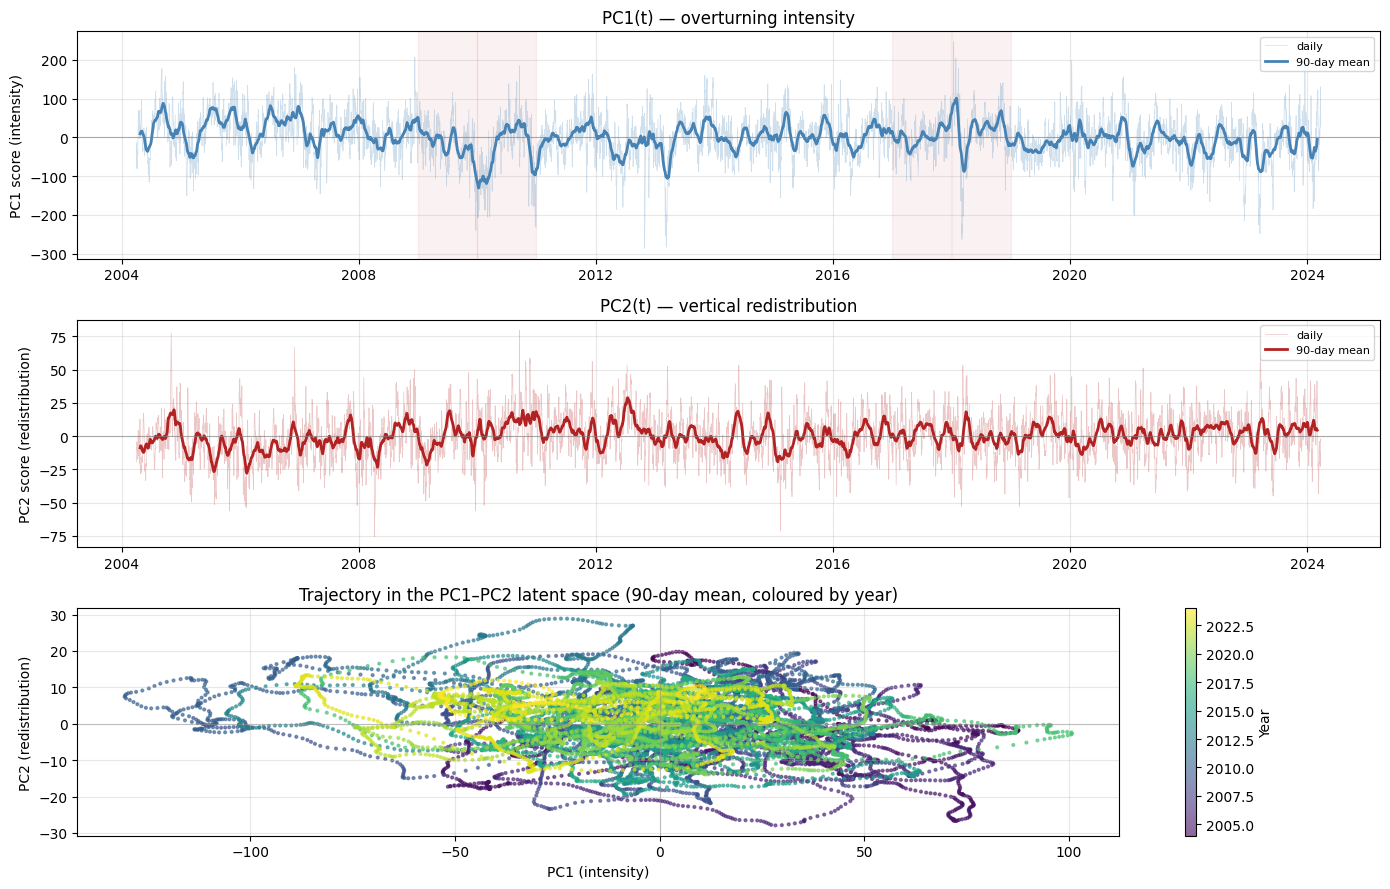

PC1 mean over 2009–2010: -23.97  (full-record mean is 0 by construction)
PC1 mean over 2017–2018: +10.73  (full-record mean is 0 by construction)


In [10]:
# Scores: each day's coordinate along each mode. scores[:, 0] = PC1(t), etc.
pc1 = scores[:, 0]
pc2 = scores[:, 1]
t = pd.to_datetime(times_clean)               # the cleaned, aligned time axis

# Rolling mean for legibility (applied to the RESULT, not the input).
# 90-day window ≈ seasonal smoothing; structure survives, daily noise softens.
win = 90
pc1_smooth = pd.Series(pc1, index=t).rolling(win, center=True).mean()
pc2_smooth = pd.Series(pc2, index=t).rolling(win, center=True).mean()

fig = plt.figure(figsize=(14, 9))

# --- PC1(t) ---
ax1 = fig.add_subplot(3, 1, 1)
ax1.plot(t, pc1, color='steelblue', alpha=0.25, linewidth=0.5, label='daily')
ax1.plot(t, pc1_smooth, color='steelblue', linewidth=2, label=f'{win}-day mean')
ax1.axhline(0, color='gray', linewidth=0.8, alpha=0.6)
ax1.set_ylabel('PC1 score (intensity)')
ax1.set_title('PC1(t) — overturning intensity')
ax1.legend(loc='upper right', fontsize=8)
# mark the known events
for yr in [2009, 2010, 2017, 2018]:
    ax1.axvspan(pd.Timestamp(f'{yr}-01-01'), pd.Timestamp(f'{yr}-12-31'),
                color='firebrick', alpha=0.06)

# --- PC2(t) ---
ax2 = fig.add_subplot(3, 1, 2, sharex=ax1)
ax2.plot(t, pc2, color='firebrick', alpha=0.25, linewidth=0.5, label='daily')
ax2.plot(t, pc2_smooth, color='firebrick', linewidth=2, label=f'{win}-day mean')
ax2.axhline(0, color='gray', linewidth=0.8, alpha=0.6)
ax2.set_ylabel('PC2 score (redistribution)')
ax2.set_title('PC2(t) — vertical redistribution')
ax2.legend(loc='upper right', fontsize=8)

# --- Trajectory in the PC1–PC2 plane, coloured by time ---
ax3 = fig.add_subplot(3, 1, 3)
sc = ax3.scatter(pc1_smooth, pc2_smooth, c=t.year, cmap='viridis',
                 s=4, alpha=0.6)
ax3.axhline(0, color='gray', linewidth=0.8, alpha=0.4)
ax3.axvline(0, color='gray', linewidth=0.8, alpha=0.4)
ax3.set_xlabel('PC1 (intensity)')
ax3.set_ylabel('PC2 (redistribution)')
ax3.set_title('Trajectory in the PC1–PC2 latent space (90-day mean, coloured by year)')
cbar = plt.colorbar(sc, ax=ax3, label='Year')

plt.tight_layout()
plt.show()

# Numeric check: do the known weak periods show as low PC1?
for label, yr in [('2009–2010', (2009, 2010)), ('2017–2018', (2017, 2018))]:
    mask = (t.year >= yr[0]) & (t.year <= yr[1])
    print(f"PC1 mean over {label}: {pc1[mask].mean():+.2f}  "
          f"(full-record mean is 0 by construction)")

## **7. Reading the modes in motion**

> **PC1(t) confirms it is the intensity mode — the 2009–2010 event is unmistakable.** PC1 dives to ~−120 during 2009–2010 (period mean **−23.97**), the same weakening seen as a fading red band in the NB01 Hovmöller, now rendered as a dip in a line. *The same physical event survives the change of representation* — direct evidence that PC1 encodes AMOC intensity, and a small proof-of-concept for the thesis claim that this system can be re-represented without losing its physics.

> **An honest correction on 2017–2018.** We expected another dip; the data shows the opposite — period mean **+10.73**, driven by a marked positive rebound around 2018 visible in the panel. This does *not* contradict the literature: the documented 2017–2018 "weakening" concerns the **long-term mean** of total AMOC transport (a slow trend), whereas PC1(t) here is dominated by **interannual** variability, in which 2018's rebound outweighs 2017's low within the window. *A low long-term trend and a low value in every individual year are different statements.* This distinction is worth stating explicitly in the writing — it is a point of methodological honesty, not a discrepancy to hide.

> **PC2(t) is near-zero-centered noise with weak structure** — consistent with its 8% share. The vertical-redistribution mode fluctuates seasonally without a strong low-frequency signature over this record.

> **The trajectory shows no clean drift — and that is the correct result.** Colouring by year (2004 violet → 2024 yellow) gives a *mixed* cloud, not a migration from one region to another. Over twenty years the AMOC wanders around its centre with occasional excursions to strongly negative PC1 (the 2009–2010 stretch, the violet reach to the left), but no structural drift in the PC1–PC2 plane. Against multidecadal thermohaline timescales, twenty years is too short to expect one (Ch.5 §5.2). A trajectory that *had* shown a clean arrow toward collapse would be suspect, not exciting. This honest, centred cloud is what a noisy system must show over this interval.

> **What this hands to Part II.** The trajectory *is* the artefact Condition 3 will encode: a navigable 2-D path, 97.9% faithful to the full vertical structure, in which a known physical event (2009–2010) appears as a legible excursion. The representational question of Part II now has a concrete object to work on.

## **8. Persist scores & loadings for downstream notebooks**

PCA is the shared substrate for two later stages. We save its outputs once so neither notebook 04 (EWS / anomaly detection) nor Part II (representation) has to recompute it.

> **What we save and why:**
> - `pc1`, `pc2` — temporal projections. PC1(t) is the 1-D intensity series the classical EWS (rolling variance, AR1) run on in NB04.
> - `eof1`, `eof2` — loadings. Part II needs these to reconstruct Ψ(z) profiles from latent coordinates (PC-space → Sv).
> - `times_clean` — the aligned 14,596-day axis, saved as ISO strings for cross-version robustness.

Saved to `03_Data/processed/` so the raw data layer is never touched.

In [11]:
from pipeline.paths import DATA_PROCESSED

# Ensure the processed-data directory exists
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
out_path = DATA_PROCESSED / "pca_vertical_scores.npz"

# Save times as ISO strings (robust across numpy versions on reload)
times_iso = np.datetime_as_string(times_clean, unit='D')

np.savez(
    out_path,
    pc1=pc1,                                  # (14596,) PC1 score per day
    pc2=pc2,                                   # (14596,) PC2 score per day
    eof1=eof1,                                 # (307,) PC1 loading, Sv
    eof2=eof2,                                 # (307,) PC2 loading, Sv
    depth=depth,                              # (307,) depth axis, m
    times=times_iso,                          # (14596,) ISO date strings
    var_explained=explained[:10],             # variance ratios, first 10 modes
)

print(f"Saved → {out_path}")
print(f"  pc1, pc2 : {pc1.shape}")
print(f"  eof1,eof2: {eof1.shape}")
print(f"  times    : {times_iso.shape}  ({times_iso[0]} → {times_iso[-1]})")

# Immediate reload check — confirm it round-trips cleanly
chk = np.load(out_path)
assert np.allclose(chk['pc1'], pc1), "pc1 did not round-trip"
assert chk['times'][0] == times_iso[0], "times did not round-trip"
print("\nRound-trip verified. Safe to use in NB04.")

Saved → C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\04_Activation_Phase\03_Data\processed\pca_vertical_scores.npz
  pc1, pc2 : (14596,)
  eof1,eof2: (307,)
  times    : (14596,)  (2004-04-02 → 2024-03-25)

Round-trip verified. Safe to use in NB04.
